# Классификация изображений кожных поражений

## Итоговая аттестационная работа по профессии «Data Science в медицине»

**Задача:** построить end-to-end pipeline для классификации фотографий кожных поражений по размеченным заболеваниям.

**Важно:** модель из этой работы не является медицинским диагностическим инструментом. Корректный сценарий применения — система поддержки принятия решений врача, где неуверенные случаи отправляются на обязательную экспертную проверку.

## 1. Импорты и настройки воспроизводимости

В разделе подключаются библиотеки, фиксируются random seeds и задаются основные параметры эксперимента. Для воспроизводимости используются единые настройки размера изображений, batch size, режима работы с предобученными весами и устройства вычислений.


In [1]:
from __future__ import annotations

import copy
import importlib.util
import json
import math
import os
import random
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from PIL import Image, ImageFile, UnidentifiedImageError
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

ALBUMENTATIONS_AVAILABLE = importlib.util.find_spec("albumentations") is not None
if ALBUMENTATIONS_AVAILABLE:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "32"))
NUM_WORKERS = int(os.getenv("NUM_WORKERS", "2"))
SAMPLE_PER_CLASS = int(os.getenv("SAMPLE_PER_CLASS", "0"))
PRETRAINED_WEIGHTS_MODE = os.getenv("PRETRAINED_WEIGHTS_MODE", "local").lower()
LOCAL_WEIGHTS_DIR = os.getenv("LOCAL_WEIGHTS_DIR")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)
print(f"Device: {DEVICE}")
print(f"Torch: {torch.__version__}, Torchvision: {torchvision.__version__}")
print(f"Albumentations available: {ALBUMENTATIONS_AVAILABLE}")
print(f"Batch size: {BATCH_SIZE}, sample per class: {SAMPLE_PER_CLASS}")


Device: cuda
Torch: 2.10.0+cu128, Torchvision: 0.25.0+cu128
Albumentations available: True
Batch size: 32, sample per class: 0


## 2. Загрузка данных и определение структуры

Датасет представлен изображениями кожных поражений и JSON-аннотациями. Поддерживаются следующие варианты структуры данных:

1. экспорт с аннотациями JSON: `meta.json`, `train/ann/*.jpg.json`, `train/img/*.jpg`, `valid/ann`, `valid/img`, `test/ann`, `test/img`;
2. структура с классами в папках: `dataset/class_name/image.jpg`;
3. таблица `metadata.csv`, где имена изображений и метки находятся в отдельных колонках.

Для основного формата с JSON-аннотациями target извлекается из диагностических тегов (`melanoma`, `nevus_or_seborrheic_keratosis`, `seborrheic_keratosis` и др.). Служебные теги, например `age_approximate` и `sex`, сохраняются как дополнительные метаданные и не используются как целевая переменная.


In [2]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
KNOWN_NON_TARGET_TAGS = {"age", "age_approx", "age_approximate", "sex", "gender", "patient_id"}
SPLIT_ALIASES = {"train": "train", "valid": "valid", "validation": "valid", "val": "valid", "test": "test"}


def iter_image_paths(root: Path):
    if not root.exists():
        return
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            yield path


def find_images(root: Path) -> list[Path]:
    return sorted(iter_image_paths(root))


def has_images(root: Path) -> bool:
    return next(iter_image_paths(root), None) is not None


def find_supervisely_roots(root: Path) -> list[Path]:
    """Find dataset roots that contain Supervisely-like ann/img folders.

    Kaggle may mount the uploaded dataset one or two levels below /kaggle/input,
    for example /kaggle/input/datasets/drmatt91/projectskill-skin-lesions.
    Therefore we search recursively and return the project root, not the broad
    /kaggle/input/datasets directory.
    """
    if not root.exists():
        return []

    roots: set[Path] = set()
    if (root / "ann").is_dir() and (root / "img").is_dir():
        roots.add(root)

    for ann_dir in root.rglob("ann"):
        if not ann_dir.is_dir():
            continue
        split_dir = ann_dir.parent
        if not (split_dir / "img").is_dir():
            continue

        split_name = split_dir.name.lower()
        if split_name in SPLIT_ALIASES:
            roots.add(split_dir.parent)
        else:
            roots.add(split_dir)

    return sorted(roots, key=lambda path: (not (path / "meta.json").exists(), len(path.parts), str(path)))


def has_supervisely_structure(root: Path) -> bool:
    """Check whether root contains ann/img folders from Supervisely-like export."""
    return bool(find_supervisely_roots(root))


def detect_data_dir() -> Path:
    """Find a reasonable dataset directory for local, Kaggle or Colab runs."""
    candidates: list[Path] = []

    env_data_dir = os.getenv("DATA_DIR")
    if env_data_dir:
        candidates.append(Path(env_data_dir))

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(path for path in kaggle_input.iterdir() if path.is_dir())
        candidates.append(kaggle_input)

    candidates.extend(
        [
            Path("/content/drive/MyDrive/ProjectSkill/data"),
            Path("/content/data"),
            Path("../data"),
            Path("data"),
        ]
    )

    existing_candidates = [candidate for candidate in candidates if candidate.exists()]

    for candidate in existing_candidates:
        supervisely_roots = find_supervisely_roots(candidate)
        if supervisely_roots:
            selected_root = supervisely_roots[0]
            if selected_root != candidate:
                print(f"Найдена вложенная папка датасета: {selected_root}")
            return selected_root

    for candidate in existing_candidates:
        if has_images(candidate):
            return candidate
    return Path(os.getenv("DATA_DIR", "../data"))


DATA_DIR = detect_data_dir()
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "/kaggle/working/outputs" if Path("/kaggle").exists() else "../outputs"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Для CSV-формата можно указать путь к metadata.csv и названия колонок.
# Для JSON-формата с meta.json/train/valid/test это не требуется.
METADATA_PATH = None  # пример: DATA_DIR / "metadata.csv"
IMAGE_ID_COLUMN = "image_id"
LABEL_COLUMN = "label"
IMAGE_ROOT = DATA_DIR

# Для Supervisely-формата можно оставить None: target-теги возьмутся из meta.json
# как теги с value_type="none", кроме служебных age/sex.
TARGET_TAG_NAMES = None  # пример: ["melanoma", "seborrheic_keratosis"]

print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
if has_supervisely_structure(DATA_DIR):
    print("Обнаружена структура JSON-разметки ann/img.")
print("Первые найденные изображения:")
for path in find_images(DATA_DIR)[:5]:
    print(" -", path)


def build_dataframe_from_folders(root: Path) -> pd.DataFrame:
    image_paths = find_images(root)
    records = []
    for path in image_paths:
        label = path.parent.name
        records.append({"image_path": str(path), "label": label, "source_format": "folders"})
    return pd.DataFrame(records)


def build_dataframe_from_metadata(
    metadata_path: Path,
    image_root: Path,
    image_id_column: str,
    label_column: str,
) -> pd.DataFrame:
    metadata = pd.read_csv(metadata_path)
    image_paths = find_images(image_root)
    image_lookup = {path.stem: path for path in image_paths}
    image_lookup.update({path.name: path for path in image_paths})
    records = []
    for _, row in metadata.iterrows():
        image_id = str(row[image_id_column])
        image_path = image_lookup.get(image_id) or image_lookup.get(Path(image_id).stem)
        if image_path is not None:
            records.append(
                {
                    "image_path": str(image_path),
                    "label": row[label_column],
                    "image_id": Path(image_path).stem,
                    "source_format": "metadata_csv",
                }
            )
    return pd.DataFrame(records)


def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def get_supervisely_target_tags(root: Path) -> set[str]:
    """Get diagnostic tag names from meta.json for Supervisely-like exports."""
    if TARGET_TAG_NAMES is not None:
        return set(TARGET_TAG_NAMES)

    meta_paths = sorted(root.rglob("meta.json"))
    if not meta_paths:
        return set()

    meta = read_json(meta_paths[0])
    target_tags = set()
    for tag in meta.get("tags", []):
        tag_name = str(tag.get("name", ""))
        value_type = str(tag.get("value_type", ""))
        if value_type == "none" and tag_name not in KNOWN_NON_TARGET_TAGS:
            target_tags.add(tag_name)
    return target_tags


def get_annotation_tags(annotation: dict) -> tuple[list[str], dict[str, object]]:
    """Return tag names and tag values from an annotation JSON."""
    tag_names = []
    tag_values = {}
    for tag in annotation.get("tags", []):
        tag_name = tag.get("name")
        if tag_name is None:
            continue
        tag_name = str(tag_name)
        tag_names.append(tag_name)
        if "value" in tag:
            tag_values[tag_name] = tag.get("value")
    return tag_names, tag_values


def find_matching_image(ann_path: Path, img_dir: Path) -> Path | None:
    """Match ann/ISIC_0000000.jpg.json to img/ISIC_0000000.jpg."""
    expected_name = ann_path.name[:-5] if ann_path.name.endswith(".json") else ann_path.stem
    direct_path = img_dir / expected_name
    if direct_path.exists():
        return direct_path

    images = find_images(img_dir)
    lookup = {path.name: path for path in images}
    lookup.update({path.stem: path for path in images})
    return lookup.get(expected_name) or lookup.get(Path(expected_name).stem)


def iter_supervisely_split_dirs(root: Path) -> list[tuple[str, Path]]:
    """Find split directories that contain ann/ and img/."""
    split_dirs = []
    if (root / "ann").is_dir() and (root / "img").is_dir():
        split_dirs.append(("all", root))

    for path in sorted(root.iterdir() if root.exists() else []):
        if not path.is_dir():
            continue
        if (path / "ann").is_dir() and (path / "img").is_dir():
            split_name = SPLIT_ALIASES.get(path.name.lower(), path.name.lower())
            split_dirs.append((split_name, path))
    return split_dirs


def build_dataframe_from_supervisely(root: Path) -> pd.DataFrame:
    """Build dataframe from meta.json + split/ann/*.json + split/img/*.jpg."""
    target_tags = get_supervisely_target_tags(root)
    if target_tags:
        print(f"Target tags from meta.json: {sorted(target_tags)}")
    else:
        print("meta.json не найден или target-теги не определены; будут использованы все теги, кроме age/sex.")

    records = []
    for split_name, split_dir in iter_supervisely_split_dirs(root):
        ann_dir = split_dir / "ann"
        img_dir = split_dir / "img"
        for ann_path in sorted(ann_dir.glob("*.json")):
            annotation = read_json(ann_path)
            tag_names, tag_values = get_annotation_tags(annotation)
            if target_tags:
                label_candidates = [tag_name for tag_name in tag_names if tag_name in target_tags]
            else:
                label_candidates = [tag_name for tag_name in tag_names if tag_name not in KNOWN_NON_TARGET_TAGS]

            if not label_candidates:
                continue

            image_path = find_matching_image(ann_path, img_dir)
            if image_path is None:
                continue

            record = {
                "image_path": str(image_path),
                "annotation_path": str(ann_path),
                "image_id": Path(image_path).stem,
                "label": label_candidates[0],
                "split": split_name,
                "source_format": "supervisely_json",
            }
            for tag_name, tag_value in tag_values.items():
                if tag_name not in label_candidates:
                    record[tag_name] = tag_value
            records.append(record)

    return pd.DataFrame(records)


def build_dataframe(root: Path) -> pd.DataFrame:
    """Choose the right dataframe builder for the detected dataset format."""
    if METADATA_PATH is not None:
        print("Используется CSV metadata format.")
        return build_dataframe_from_metadata(
            METADATA_PATH,
            IMAGE_ROOT,
            IMAGE_ID_COLUMN,
            LABEL_COLUMN,
        )
    if has_supervisely_structure(root):
        print("Обнаружен формат meta.json + ann/img. Используется JSON-разметка.")
        return build_dataframe_from_supervisely(root)

    print("Формат ann/img не найден. Используется извлечение label из имени папки класса.")
    return build_dataframe_from_folders(root)


df = build_dataframe(DATA_DIR)

if SAMPLE_PER_CLASS > 0 and len(df) > 0:
    group_columns = ["label"]
    if "split" in df.columns:
        group_columns = ["split", "label"]
    df = (
        df.groupby(group_columns, group_keys=False)
        .apply(lambda group: group.sample(min(len(group), SAMPLE_PER_CLASS), random_state=SEED))
        .reset_index(drop=True)
    )
    print(f"Включён быстрый режим: максимум {SAMPLE_PER_CLASS} изображений на класс.")

print(f"Всего найдено размеченных изображений: {len(df)}")
if "source_format" in df.columns and len(df) > 0:
    print("Формат данных:", df["source_format"].iloc[0])
if "split" in df.columns:
    print("Разбиение из датасета:")
    print(df["split"].value_counts())
df.head()


Найдена вложенная папка датасета: /kaggle/input/datasets/drmatt91/projectskill-skin-lesions
DATA_DIR: /kaggle/input/datasets/drmatt91/projectskill-skin-lesions
OUTPUT_DIR: /kaggle/working/outputs
Обнаружена структура JSON-разметки ann/img.
Первые найденные изображения:
 - /kaggle/input/datasets/drmatt91/projectskill-skin-lesions/test/img/ISIC_0012266.jpg
 - /kaggle/input/datasets/drmatt91/projectskill-skin-lesions/test/img/ISIC_0012273.jpg
 - /kaggle/input/datasets/drmatt91/projectskill-skin-lesions/test/img/ISIC_0012757.jpg
 - /kaggle/input/datasets/drmatt91/projectskill-skin-lesions/test/img/ISIC_0013109.jpg
 - /kaggle/input/datasets/drmatt91/projectskill-skin-lesions/test/img/ISIC_0013203.jpg
Обнаружен формат meta.json + ann/img. Используется JSON-разметка.
Target tags from meta.json: ['melanoma', 'melanoma_or_nevus', 'nevus_or_seborrheic_keratosis', 'seborrheic_keratosis']
Всего найдено размеченных изображений: 112
Формат данных: supervisely_json
Разбиение из датасета:
split
train 

,image_path,annotation_path,image_id,label,split,source_format,age_approximate,sex
0,/kaggle/input/datasets/drmatt91/projectskill-s...,/kaggle/input/datasets/drmatt91/projectskill-s...,ISIC_0012266,nevus_or_seborrheic_keratosis,test,supervisely_json,60,male
1,/kaggle/input/datasets/drmatt91/projectskill-s...,/kaggle/input/datasets/drmatt91/projectskill-s...,ISIC_0012273,nevus_or_seborrheic_keratosis,test,supervisely_json,65,male
2,/kaggle/input/datasets/drmatt91/projectskill-s...,/kaggle/input/datasets/drmatt91/projectskill-s...,ISIC_0012757,nevus_or_seborrheic_keratosis,test,supervisely_json,60,female
3,/kaggle/input/datasets/drmatt91/projectskill-s...,/kaggle/input/datasets/drmatt91/projectskill-s...,ISIC_0013109,nevus_or_seborrheic_keratosis,test,supervisely_json,50,female
4,/kaggle/input/datasets/drmatt91/projectskill-s...,/kaggle/input/datasets/drmatt91/projectskill-s...,ISIC_0013203,nevus_or_seborrheic_keratosis,test,supervisely_json,75,female


## 3. Проверка и очистка изображений

Проверяются читаемость файлов, формат, размеры, число каналов, яркость, размер файла и дубликаты путей. Битые или нечитаемые изображения исключаются из дальнейшей работы. Для ускорения повторных запусков результаты проверки сохраняются в кэш `OUTPUT_DIR/image_info_cache.csv`.


In [3]:
def inspect_image(path: str) -> dict:
    result = {
        "image_path": path,
        "is_valid": False,
        "width": np.nan,
        "height": np.nan,
        "channels": np.nan,
        "image_format": None,
        "file_size": np.nan,
        "aspect_ratio": np.nan,
        "mean_brightness": np.nan,
    }
    try:
        file_path = Path(path)
        with Image.open(file_path) as image:
            image_format = image.format
            width, height = image.size
            image = image.convert("RGB")
            channels = len(image.getbands())

            # Для ускорения считаем яркость по thumbnail, а не по полному 12 GB датасету.
            brightness_image = image.copy()
            brightness_image.thumbnail((64, 64))
            mean_brightness = float(np.asarray(brightness_image).mean())

            result.update(
                {
                    "is_valid": True,
                    "width": width,
                    "height": height,
                    "channels": channels,
                    "image_format": image_format,
                    "file_size": file_path.stat().st_size,
                    "aspect_ratio": width / height,
                    "mean_brightness": mean_brightness,
                }
            )
    except (FileNotFoundError, UnidentifiedImageError, OSError, ValueError):
        pass
    return result


def inspect_images_with_progress(paths: Iterable[str]) -> pd.DataFrame:
    """Inspect images with visible progress so Kaggle does not look frozen."""
    paths = list(paths)
    total = len(paths)
    if total == 0:
        return pd.DataFrame()

    print(f"Начинаю проверку изображений: {total} файлов.", flush=True)
    print("Если датасет большой, эта ячейка может выполняться несколько минут.", flush=True)

    records = []
    progress_step = max(1, min(100, total // 10))
    started_at = time.time()
    for idx, path in enumerate(paths, start=1):
        records.append(inspect_image(path))
        if idx == 1 or idx == total or idx % progress_step == 0:
            elapsed = time.time() - started_at
            print(f"Проверено {idx}/{total} изображений за {elapsed:.1f} сек.", flush=True)
    return pd.DataFrame(records)


if len(df) == 0:
    raise ValueError(
        "Датасет не найден. Проверьте DATA_DIR. Для JSON-формата нужна папка с meta.json и train/valid/test, внутри которых есть ann/ и img/."
    )

image_info_cache_path = OUTPUT_DIR / "image_info_cache.csv"
use_image_info_cache = os.getenv("USE_IMAGE_INFO_CACHE", "1") == "1"

if use_image_info_cache and image_info_cache_path.exists():
    cached_image_info = pd.read_csv(image_info_cache_path)
    cached_paths = set(cached_image_info["image_path"].astype(str))
    current_paths = set(df["image_path"].astype(str))
    if current_paths.issubset(cached_paths):
        print(f"Используется кэш проверки изображений: {image_info_cache_path}", flush=True)
        image_info = cached_image_info[cached_image_info["image_path"].isin(current_paths)].copy()
    else:
        print("Кэш найден, но не покрывает текущий датасет. Проверяю изображения заново.", flush=True)
        image_info = inspect_images_with_progress(df["image_path"])
        image_info.to_csv(image_info_cache_path, index=False)
else:
    image_info = inspect_images_with_progress(df["image_path"])
    image_info.to_csv(image_info_cache_path, index=False)
    print(f"Кэш проверки сохранён: {image_info_cache_path}", flush=True)

df = df.merge(image_info, on="image_path", how="left")

invalid_count = int((~df["is_valid"]).sum())
df = df[df["is_valid"]].drop_duplicates(subset="image_path").reset_index(drop=True)

class_names = sorted(df["label"].astype(str).unique())
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
df["label"] = df["label"].astype(str)
df["label_id"] = df["label"].map(class_to_idx)

print(f"Битых/непрочитанных изображений исключено: {invalid_count}")
print(f"Изображений после очистки: {len(df)}")
print(f"Классов: {len(class_names)}")
print(class_to_idx)
df.head()


Начинаю проверку изображений: 112 файлов.
Если датасет большой, эта ячейка может выполняться несколько минут.
Проверено 1/112 изображений за 0.3 сек.
Проверено 11/112 изображений за 2.2 сек.
Проверено 22/112 изображений за 8.0 сек.
Проверено 33/112 изображений за 10.3 сек.
Проверено 44/112 изображений за 10.6 сек.
Проверено 55/112 изображений за 11.3 сек.
Проверено 66/112 изображений за 11.8 сек.
Проверено 77/112 изображений за 12.5 сек.
Проверено 88/112 изображений за 14.0 сек.
Проверено 99/112 изображений за 16.5 сек.
Проверено 110/112 изображений за 21.0 сек.
Проверено 112/112 изображений за 21.7 сек.
Кэш проверки сохранён: /kaggle/working/outputs/image_info_cache.csv
Битых/непрочитанных изображений исключено: 0
Изображений после очистки: 112
Классов: 2
{'melanoma': 0, 'nevus_or_seborrheic_keratosis': 1}


,image_path,annotation_path,image_id,label,split,source_format,age_approximate,sex,is_valid,width,height,channels,image_format,file_size,aspect_ratio,mean_brightness,label_id
0,/kaggle/input/datasets/drmatt91/projectskill-s...,/kaggle/input/datasets/drmatt91/projectskill-s...,ISIC_0012266,nevus_or_seborrheic_keratosis,test,supervisely_json,60,male,True,4288,2848,3,JPEG,4565936,1.505618,146.556565,1
1,/kaggle/input/datasets/drmatt91/projectskill-s...,/kaggle/input/datasets/drmatt91/projectskill-s...,ISIC_0012273,nevus_or_seborrheic_keratosis,test,supervisely_json,65,male,True,3008,2000,3,JPEG,2733516,1.504000,105.714995,1
2,/kaggle/input/datasets/drmatt91/projectskill-s...,/kaggle/input/datasets/drmatt91/projectskill-s...,ISIC_0012757,nevus_or_seborrheic_keratosis,test,supervisely_json,60,female,True,3872,2592,3,JPEG,3689672,1.493827,156.594598,1
3,/kaggle/input/datasets/drmatt91/projectskill-s...,/kaggle/input/datasets/drmatt91/projectskill-s...,ISIC_0013109,nevus_or_seborrheic_keratosis,test,supervisely_json,50,female,True,3008,2000,3,JPEG,3131375,1.504000,148.481468,1
4,/kaggle/input/datasets/drmatt91/projectskill-s...,/kaggle/input/datasets/drmatt91/projectskill-s...,ISIC_0013203,nevus_or_seborrheic_keratosis,test,supervisely_json,75,female,True,3008,2000,3,JPEG,2637146,1.504000,159.617369,1


### Вывод по проверке данных

На этапе проверки формируется таблица с путями к изображениям, метками классов и техническими характеристиками файлов. Нечитаемые изображения исключаются из анализа. Все изображения при загрузке приводятся к RGB-формату, что обеспечивает единый вход для нейросетевых моделей.

Ограничение разделения данных: если в исходной разметке отсутствует `patient_id`, невозможно гарантировать patient-level split. Это создаёт риск попадания похожих изображений одного пациента в разные выборки и должно учитываться при интерпретации качества.


## 4. EDA: распределение классов, примеры и статистики изображений

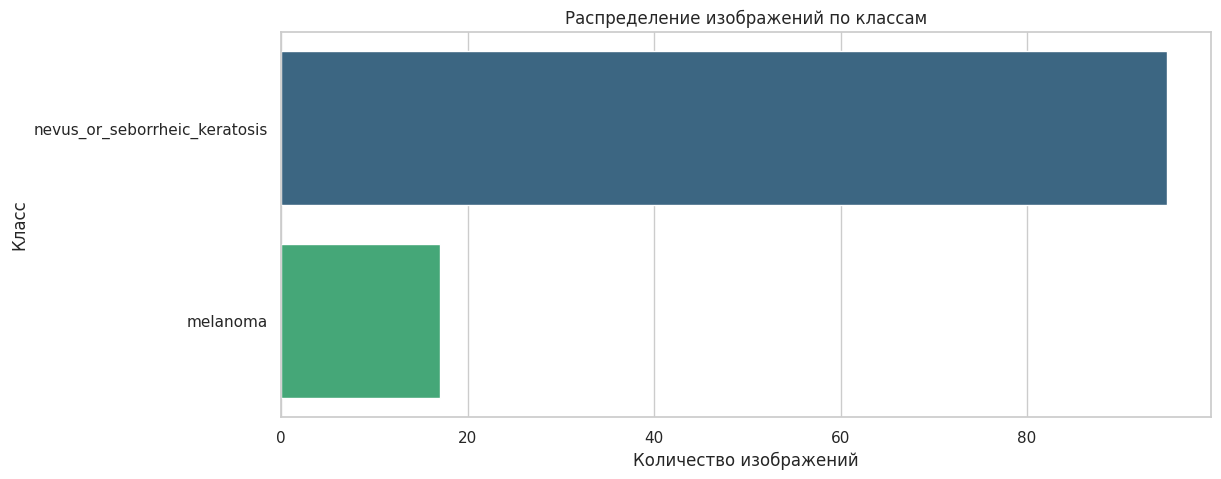

label
nevus_or_seborrheic_keratosis    95
melanoma                         17
Name: count, dtype: int64
Доля самого частого класса: 84.82%
Доля самого редкого класса: 15.18%


In [4]:
def plot_class_distribution(data: pd.DataFrame) -> None:
    plt.figure(figsize=(12, 5))
    order = data["label"].value_counts().index
    sns.countplot(data=data, y="label", order=order, palette="viridis")
    plt.title("Распределение изображений по классам")
    plt.xlabel("Количество изображений")
    plt.ylabel("Класс")
    plt.show()

plot_class_distribution(df)
class_distribution = df["label"].value_counts()
print(class_distribution)
print(f"Доля самого частого класса: {class_distribution.max() / len(df):.2%}")
print(f"Доля самого редкого класса: {class_distribution.min() / len(df):.2%}")


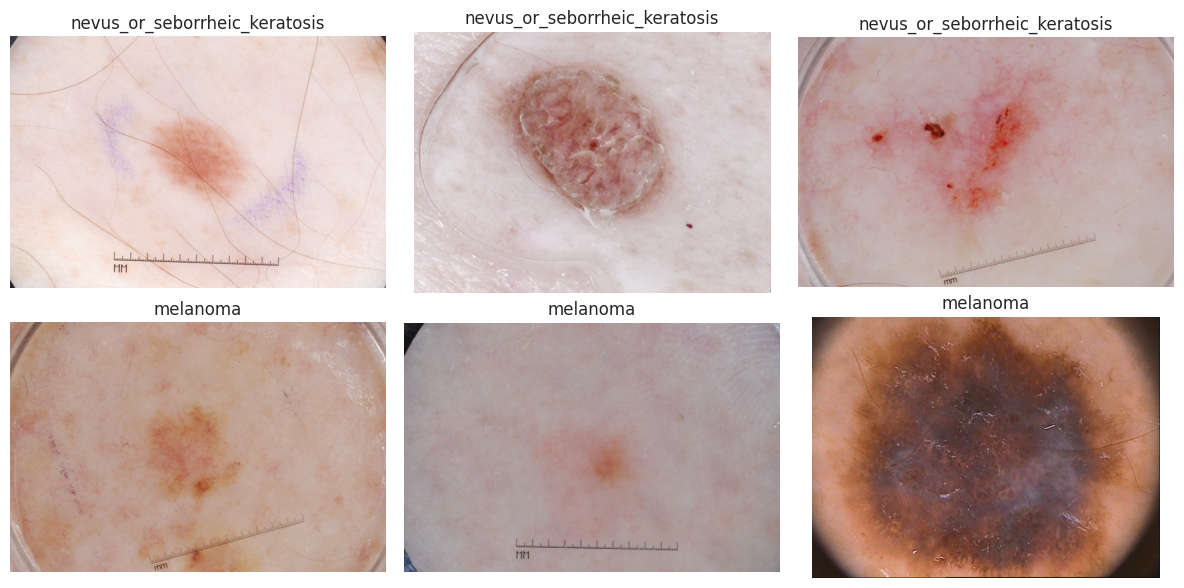

In [5]:
def show_class_examples(
    data: pd.DataFrame,
    images_per_class: int = 3,
    max_classes: int = 10,
) -> None:
    selected_classes = data["label"].value_counts().head(max_classes).index
    fig, axes = plt.subplots(
        len(selected_classes),
        images_per_class,
        figsize=(4 * images_per_class, 3 * len(selected_classes)),
    )
    if len(selected_classes) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row_idx, label in enumerate(selected_classes):
        sample = data[data["label"] == label].sample(
            min(images_per_class, (data["label"] == label).sum()),
            random_state=SEED,
        )
        for col_idx in range(images_per_class):
            ax = axes[row_idx, col_idx]
            ax.axis("off")
            if col_idx < len(sample):
                image = Image.open(sample.iloc[col_idx]["image_path"]).convert("RGB")
                ax.imshow(image)
                ax.set_title(label)
    plt.tight_layout()
    plt.show()

show_class_examples(df, images_per_class=3, max_classes=min(8, len(class_names)))


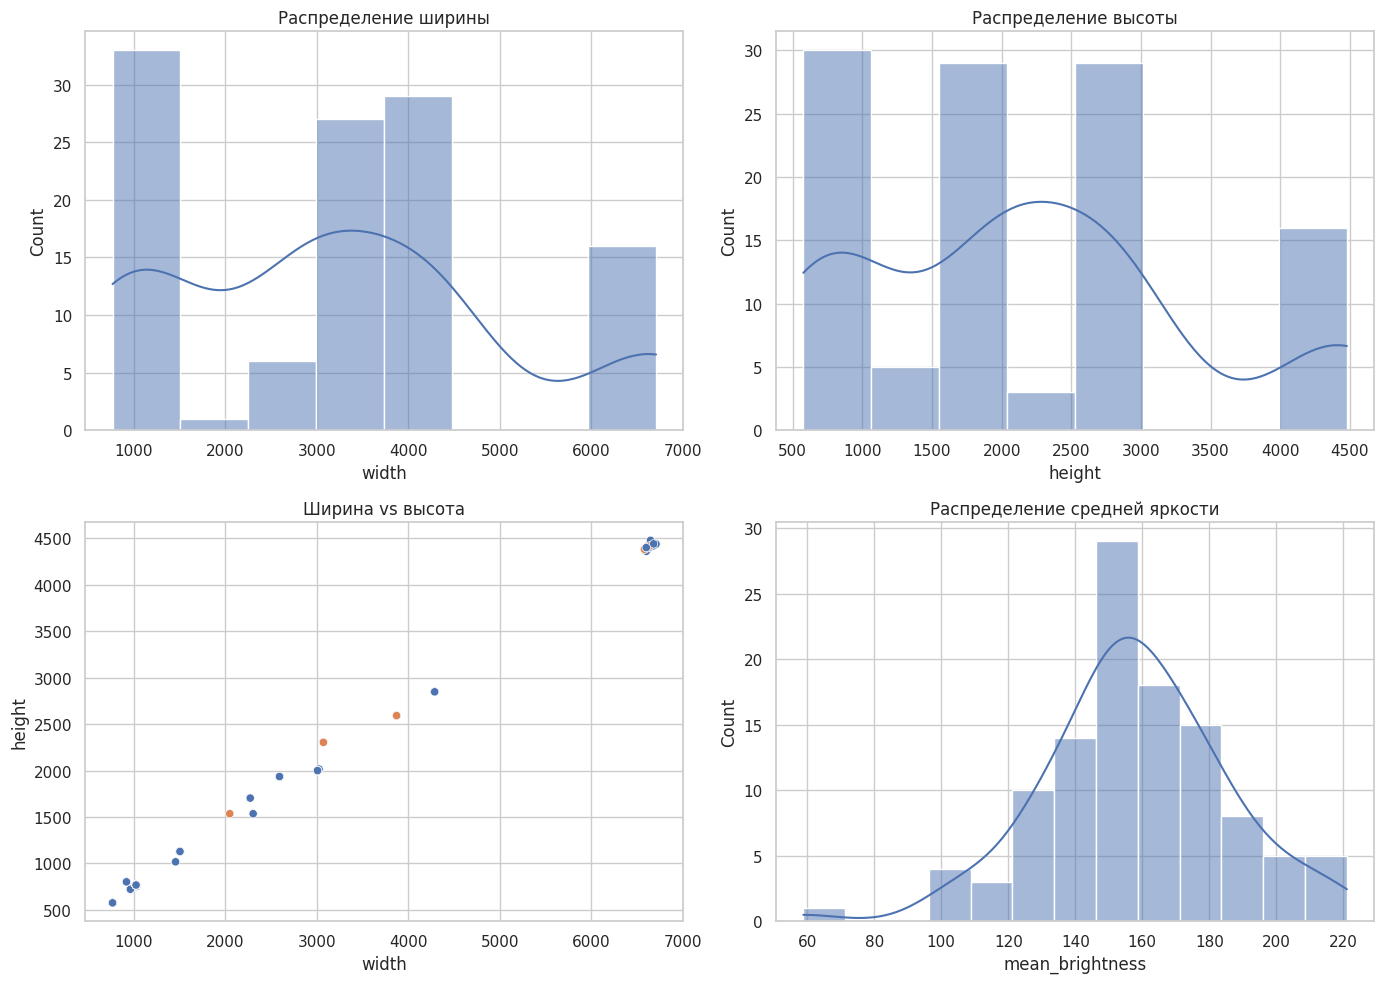

,width,height,aspect_ratio,mean_brightness,file_size
count,112.000000,112.000000,112.000000,112.000000,1.120000e+02
mean,3218.839286,2186.910714,1.435747,157.755904,4.243618e+06
std,1854.560935,1196.832965,0.093256,27.363205,5.483098e+06
min,767.000000,576.000000,1.145885,58.851811,4.286100e+04
25%,1027.000000,802.000000,1.333333,143.402711,3.249542e+05
50%,3008.000000,2000.000000,1.500913,156.520331,2.652512e+06
75%,4288.000000,2848.000000,1.505154,173.908491,4.575592e+06
max,6708.000000,4479.000000,1.513873,221.036892,2.087940e+07


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df["width"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Распределение ширины")
sns.histplot(df["height"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Распределение высоты")
sns.scatterplot(data=df, x="width", y="height", hue="label", ax=axes[1, 0], legend=False)
axes[1, 0].set_title("Ширина vs высота")
sns.histplot(df["mean_brightness"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Распределение средней яркости")
plt.tight_layout()
plt.show()

df[["width", "height", "aspect_ratio", "mean_brightness", "file_size"]].describe()


### Выводы по EDA

EDA включает анализ распределения классов, визуальную проверку примеров изображений, оценку размеров, aspect ratio и яркости. При наличии дисбаланса классов в моделировании используются stratified split, class weights, balanced accuracy и macro F1.

Изображения отличаются по размеру, освещению и масштабу, поэтому в pipeline применяется resize до 224×224, нормализация и умеренные аугментации. Визуальная похожесть кожных поражений разных типов делает необходимым анализ confusion matrix и ошибочных предсказаний.


## 5. Предобработка и аугментации

Для моделей с ImageNet-весами применяется нормализация ImageNet. Случайные аугментации используются только для train-выборки; validation/test получают только детерминированные преобразования.

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

if ALBUMENTATIONS_AVAILABLE:
    train_transform = A.Compose(
        [
            A.Resize(IMAGE_SIZE, IMAGE_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.ShiftScaleRotate(
                shift_limit=0.05,
                scale_limit=0.10,
                rotate_limit=20,
                p=0.5,
            ),
            A.RandomBrightnessContrast(
                brightness_limit=0.15,
                contrast_limit=0.15,
                p=0.4,
            ),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]
    )
    valid_transform = A.Compose(
        [
            A.Resize(IMAGE_SIZE, IMAGE_SIZE),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]
    )
else:
    train_transform = transforms.Compose(
        [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(brightness=0.15, contrast=0.15),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
    )
    valid_transform = transforms.Compose(
        [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
    )

def denormalize_tensor(tensor: torch.Tensor) -> np.ndarray:
    image = tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = image * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(image, 0, 1)


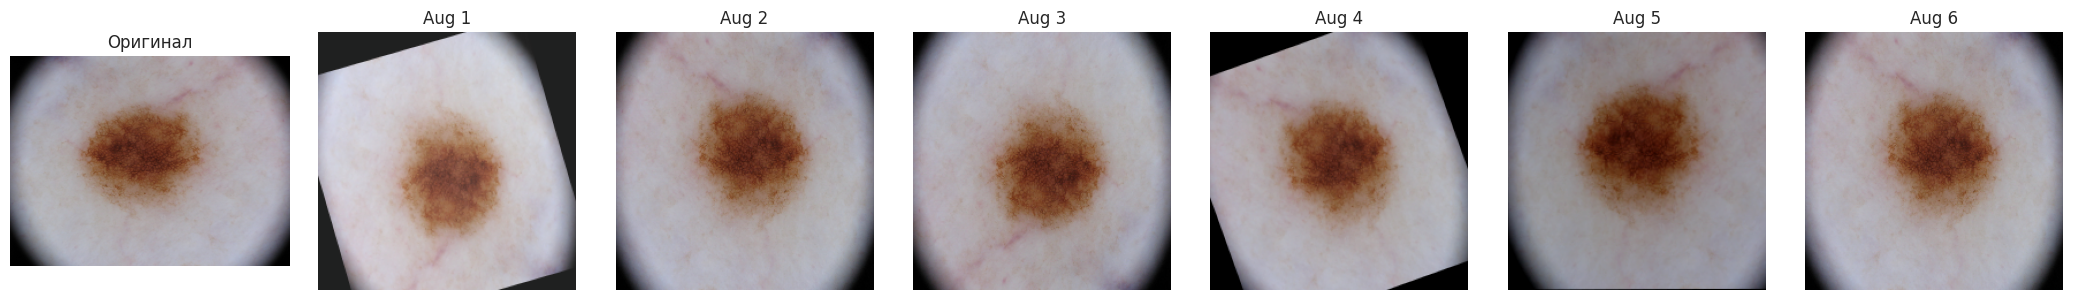

In [8]:
def apply_transform(image: Image.Image, transform: Callable) -> torch.Tensor:
    if ALBUMENTATIONS_AVAILABLE:
        transformed = transform(image=np.asarray(image))
        return transformed["image"]
    return transform(image)

def show_augmentations(data: pd.DataFrame, n_augmented: int = 6) -> None:
    sample_path = data.sample(1, random_state=SEED).iloc[0]["image_path"]
    image = Image.open(sample_path).convert("RGB")
    fig, axes = plt.subplots(1, n_augmented + 1, figsize=(3 * (n_augmented + 1), 3))
    axes[0].imshow(image)
    axes[0].set_title("Оригинал")
    axes[0].axis("off")
    for idx in range(n_augmented):
        transformed = apply_transform(image, train_transform)
        axes[idx + 1].imshow(denormalize_tensor(transformed))
        axes[idx + 1].set_title(f"Aug {idx + 1}")
        axes[idx + 1].axis("off")
    plt.tight_layout()
    plt.show()

show_augmentations(df)


## 6. Разделение на train/validation/test

Если датасет уже содержит папки `train`, `valid` и `test`, используется готовое разбиение. Если готового split нет, применяется стратифицированное разбиение 70% / 15% / 15% по `label_id`.

Если в данных есть `patient_id`, для промышленного решения предпочтителен patient-level split, чтобы изображения одного пациента не попадали в разные выборки.


In [9]:
if "split" in df.columns and {"train", "valid", "test"}.issubset(set(df["split"].astype(str))):
    train_df = df[df["split"] == "train"].copy()
    valid_df = df[df["split"] == "valid"].copy()
    test_df = df[df["split"] == "test"].copy()
    print("Используется готовое разбиение из папок train/valid/test.")
else:
    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        stratify=df["label_id"],
        random_state=SEED,
    )
    valid_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df["label_id"],
        random_state=SEED,
    )
    print("Готовое разбиение не найдено. Используется stratified split 70/15/15.")

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(train_df.shape, valid_df.shape, test_df.shape)
print("Train distribution:")
print(train_df["label"].value_counts(normalize=True).round(3))
print("Validation distribution:")
print(valid_df["label"].value_counts(normalize=True).round(3))
print("Test distribution:")
print(test_df["label"].value_counts(normalize=True).round(3))


Используется готовое разбиение из папок train/valid/test.
(76, 17) (5, 17) (31, 17)
Train distribution:
label
nevus_or_seborrheic_keratosis    0.829
melanoma                         0.171
Name: proportion, dtype: float64
Validation distribution:
label
nevus_or_seborrheic_keratosis    1.0
Name: proportion, dtype: float64
Test distribution:
label
nevus_or_seborrheic_keratosis    0.871
melanoma                         0.129
Name: proportion, dtype: float64


## 7. Dataset и DataLoader

In [10]:
class SkinLesionDataset(Dataset):
    def __init__(self, data: pd.DataFrame, transform: Callable | None = None) -> None:
        self.data = data.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        row = self.data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label_id"])
        if self.transform is not None:
            image = apply_transform(image, self.transform)
        return image, label

def create_class_weights(data: pd.DataFrame) -> torch.Tensor:
    counts = data["label_id"].value_counts().sort_index().values
    weights = counts.sum() / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float32)

class_weights = create_class_weights(train_df).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

train_dataset = SkinLesionDataset(train_df, transform=train_transform)
valid_dataset = SkinLesionDataset(valid_df, transform=valid_transform)
test_dataset = SkinLesionDataset(test_df, transform=valid_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train dataset: {len(train_dataset)} изображений")
print(f"Validation dataset: {len(valid_dataset)} изображений")
print(f"Test dataset: {len(test_dataset)} изображений")
print(f"DataLoader batch_size={BATCH_SIZE}, num_workers={NUM_WORKERS}, device={DEVICE}")
print(f"Class weights: {class_weights.detach().cpu().numpy().round(3).tolist()}")
print("Dataset и DataLoader созданы. Следующая ячейка начнёт подготовку моделей.")


Train dataset: 76 изображений
Validation dataset: 5 изображений
Test dataset: 31 изображений
DataLoader batch_size=32, num_workers=2, device=cuda
Class weights: [2.9230000972747803, 0.6029999852180481]
Dataset и DataLoader созданы. Следующая ячейка начнёт подготовку моделей.


## 8. Модели: ResNet18 и MobileNetV3

Для моделирования используются две компактные CNN-архитектуры: `ResNet18` и `MobileNetV3-Large`. Обе модели подходят для transfer learning и могут использовать предобученные ImageNet-веса. Последний классификационный слой заменяется на слой с числом классов текущего датасета.

Экспериментальная схема включает обучение классификационной головы при замороженном backbone и последующий fine-tuning лучшей модели с меньшим learning rate.


In [11]:
TORCHVISION_WEIGHT_FILES = {
    "resnet18": "resnet18-f37072fd.pth",
    "mobilenet_v3_large": "mobilenet_v3_large-8738ca79.pth",
}

TORCHVISION_WEIGHT_URLS = {
    "resnet18": "https://download.pytorch.org/models/resnet18-f37072fd.pth",
    "mobilenet_v3_large": "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth",
}


def get_weight_search_dirs() -> list[Path]:
    """Return directories where offline pretrained weights may be stored."""
    candidates: list[Path] = []
    if LOCAL_WEIGHTS_DIR:
        candidates.append(Path(LOCAL_WEIGHTS_DIR))
    candidates.extend(
        [
            Path("/kaggle/input/torchvision-imagenet-weights"),
            Path("/kaggle/input"),
            Path("/content/drive/MyDrive/ProjectSkill/weights"),
            Path("../weights"),
            Path("weights"),
        ]
    )
    return [path for path in candidates if path.exists()]


def find_local_weight_file(model_name: str) -> Path | None:
    """Find a local torchvision .pth file for a pretrained model."""
    file_name = TORCHVISION_WEIGHT_FILES[model_name]
    for directory in get_weight_search_dirs():
        direct_path = directory / file_name
        if direct_path.exists():
            return direct_path
        matches = list(directory.rglob(file_name))
        if matches:
            return matches[0]
    return None


def load_local_state_dict(model: nn.Module, model_name: str) -> None:
    """Load ImageNet weights from a local .pth file without internet access."""
    weight_path = find_local_weight_file(model_name)
    if weight_path is None:
        search_dirs = ", ".join(str(path) for path in get_weight_search_dirs())
        expected_file = TORCHVISION_WEIGHT_FILES[model_name]
        download_url = TORCHVISION_WEIGHT_URLS[model_name]
        raise FileNotFoundError(
            f"Не найден файл предобученных весов {expected_file}. "
            f"Файл можно подготовить по ссылке: {download_url}. "
            f"Поместите файл в директорию весов или укажите LOCAL_WEIGHTS_DIR. "
            f"Проверенные папки: {search_dirs or 'нет существующих папок'}."
        )
    state_dict = torch.load(weight_path, map_location="cpu")
    if isinstance(state_dict, dict) and "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]
    model.load_state_dict(state_dict)
    print(f"Loaded pretrained weights for {model_name}: {weight_path}")


def create_resnet18(num_classes: int, pretrained: bool = True) -> nn.Module:
    if pretrained and PRETRAINED_WEIGHTS_MODE == "download":
        weights = models.ResNet18_Weights.IMAGENET1K_V1
        model = models.resnet18(weights=weights)
    else:
        model = models.resnet18(weights=None)
        if pretrained and PRETRAINED_WEIGHTS_MODE == "local":
            load_local_state_dict(model, "resnet18")
        elif pretrained and PRETRAINED_WEIGHTS_MODE != "none":
            raise ValueError(
                "PRETRAINED_WEIGHTS_MODE должен быть 'local', 'download' или 'none'."
            )
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def create_mobilenet_v3(num_classes: int, pretrained: bool = True) -> nn.Module:
    if pretrained and PRETRAINED_WEIGHTS_MODE == "download":
        weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
        model = models.mobilenet_v3_large(weights=weights)
    else:
        model = models.mobilenet_v3_large(weights=None)
        if pretrained and PRETRAINED_WEIGHTS_MODE == "local":
            load_local_state_dict(model, "mobilenet_v3_large")
        elif pretrained and PRETRAINED_WEIGHTS_MODE != "none":
            raise ValueError(
                "PRETRAINED_WEIGHTS_MODE должен быть 'local', 'download' или 'none'."
            )
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def set_backbone_trainable(model: nn.Module, trainable: bool) -> None:
    for param in model.parameters():
        param.requires_grad = trainable


def train_classifier_head(model: nn.Module) -> None:
    set_backbone_trainable(model, False)
    if hasattr(model, "fc"):
        for param in model.fc.parameters():
            param.requires_grad = True
    if hasattr(model, "classifier"):
        for param in model.classifier.parameters():
            param.requires_grad = True


## 9. Цикл обучения и оценка по эпохам

In [12]:
@dataclass
class ExperimentConfig:
    model_name: str
    learning_rate: float
    batch_size: int
    epochs: int
    fine_tuning: bool
    weight_decay: float = 1e-4


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion_fn: nn.Module,
    optimizer: optim.Optimizer | None = None,
    phase: str = "epoch",
) -> dict:
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    losses, predictions, targets = [], [], []

    total_batches = len(loader)
    progress_step = max(1, total_batches // 5)

    for batch_idx, (images, labels) in enumerate(loader, start=1):
        if batch_idx == 1 or batch_idx == total_batches or batch_idx % progress_step == 0:
            print(f"{phase}: batch {batch_idx}/{total_batches}", flush=True)
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion_fn(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        losses.append(loss.item())
        predictions.extend(logits.argmax(dim=1).detach().cpu().numpy())
        targets.extend(labels.detach().cpu().numpy())

    return {
        "loss": float(np.mean(losses)),
        "accuracy": accuracy_score(targets, predictions),
        "macro_f1": f1_score(targets, predictions, average="macro", zero_division=0),
    }


def fit_model(
    model: nn.Module,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    config: ExperimentConfig,
    criterion_fn: nn.Module,
) -> tuple[nn.Module, pd.DataFrame]:
    model = model.to(DEVICE)
    optimizer = optim.AdamW(
        filter(lambda parameter: parameter.requires_grad, model.parameters()),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )
    best_model_state = copy.deepcopy(model.state_dict())
    best_macro_f1 = -math.inf
    history = []

    for epoch in range(1, config.epochs + 1):
        start_time = time.time()
        print(f"Начинаю эпоху {epoch}/{config.epochs}: {config.model_name}", flush=True)
        train_metrics = run_epoch(
            model,
            train_loader,
            criterion_fn,
            optimizer,
            phase=f"{config.model_name} train epoch {epoch}",
        )
        valid_metrics = run_epoch(
            model,
            valid_loader,
            criterion_fn,
            phase=f"{config.model_name} valid epoch {epoch}",
        )
        scheduler.step(valid_metrics["loss"])

        row = {
            "epoch": epoch,
            "model": config.model_name,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_metrics["loss"],
            "valid_loss": valid_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "valid_accuracy": valid_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "valid_macro_f1": valid_metrics["macro_f1"],
            "seconds": time.time() - start_time,
        }
        history.append(row)
        print(row)

        if valid_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = valid_metrics["macro_f1"]
            best_model_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_state)
    return model, pd.DataFrame(history)


def plot_training_history(history: pd.DataFrame, title: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["epoch"], history["train_loss"], label="train")
    axes[0].plot(history["epoch"], history["valid_loss"], label="validation")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history["epoch"], history["train_macro_f1"], label="train")
    axes[1].plot(history["epoch"], history["valid_macro_f1"], label="validation")
    axes[1].set_title(f"{title}: macro F1")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


## 10. Эксперименты и подбор гиперпараметров

Для сравнения обучаются две предобученные архитектуры с одинаковой схемой оптимизации. Основная метрика выбора модели — validation macro F1, поскольку она лучше отражает качество на редких классах при дисбалансе выборки.


Loaded pretrained weights for resnet18: /kaggle/input/datasets/drmatt91/weights/resnet18-f37072fd.pth
Начинаю эпоху 1/5: resnet18_head
resnet18_head train epoch 1: batch 1/3
resnet18_head train epoch 1: batch 2/3
resnet18_head train epoch 1: batch 3/3
resnet18_head valid epoch 1: batch 1/1
{'epoch': 1, 'model': 'resnet18_head', 'lr': 0.001, 'train_loss': 0.7463478048642477, 'valid_loss': 0.8327251076698303, 'train_accuracy': 0.7368421052631579, 'valid_accuracy': 0.2, 'train_macro_f1': 0.536019536019536, 'valid_macro_f1': 0.16666666666666666, 'seconds': 6.306797981262207}
Начинаю эпоху 2/5: resnet18_head
resnet18_head train epoch 2: batch 1/3
resnet18_head train epoch 2: batch 2/3
resnet18_head train epoch 2: batch 3/3
resnet18_head valid epoch 2: batch 1/1
{'epoch': 2, 'model': 'resnet18_head', 'lr': 0.001, 'train_loss': 0.7625624537467957, 'valid_loss': 1.0002669095993042, 'train_accuracy': 0.27631578947368424, 'valid_accuracy': 0.0, 'train_macro_f1': 0.2761904761904762, 'valid_macro_

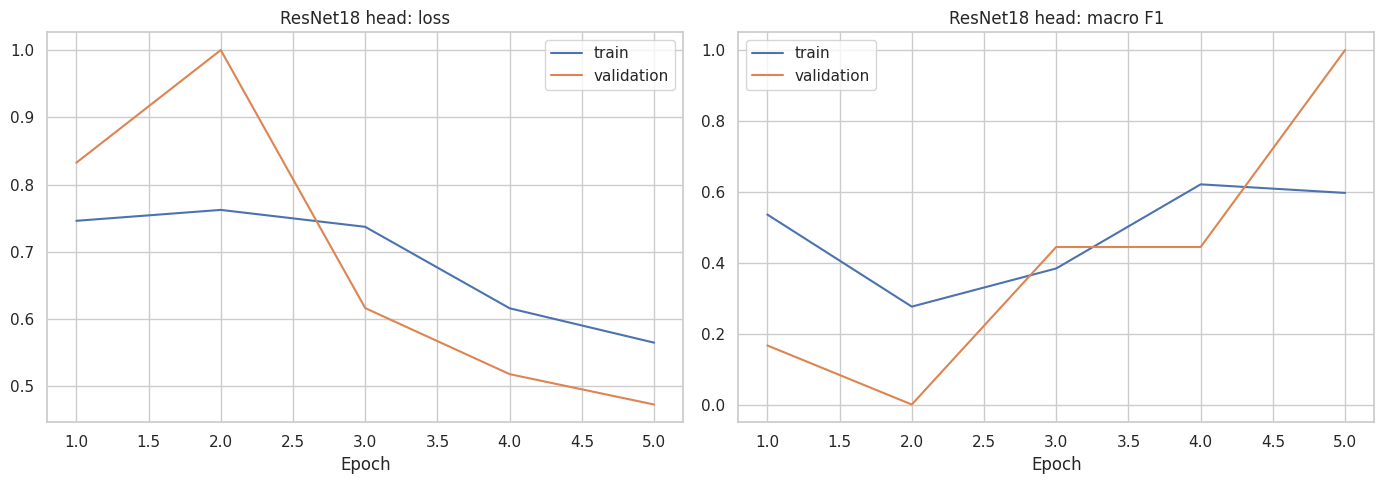

Loaded pretrained weights for mobilenet_v3_large: /kaggle/input/datasets/drmatt91/weights/mobilenet_v3_large-8738ca79.pth
Начинаю эпоху 1/5: mobilenet_v3_head
mobilenet_v3_head train epoch 1: batch 1/3
mobilenet_v3_head train epoch 1: batch 2/3
mobilenet_v3_head train epoch 1: batch 3/3
mobilenet_v3_head valid epoch 1: batch 1/1
{'epoch': 1, 'model': 'mobilenet_v3_head', 'lr': 0.001, 'train_loss': 0.6593567927678426, 'valid_loss': 0.8458680510520935, 'train_accuracy': 0.6052631578947368, 'valid_accuracy': 0.2, 'train_macro_f1': 0.5202020202020202, 'valid_macro_f1': 0.16666666666666666, 'seconds': 5.940996885299683}
Начинаю эпоху 2/5: mobilenet_v3_head
mobilenet_v3_head train epoch 2: batch 1/3
mobilenet_v3_head train epoch 2: batch 2/3
mobilenet_v3_head train epoch 2: batch 3/3
mobilenet_v3_head valid epoch 2: batch 1/1
{'epoch': 2, 'model': 'mobilenet_v3_head', 'lr': 0.001, 'train_loss': 0.44578303893407184, 'valid_loss': 0.9120376110076904, 'train_accuracy': 0.8157894736842105, 'vali

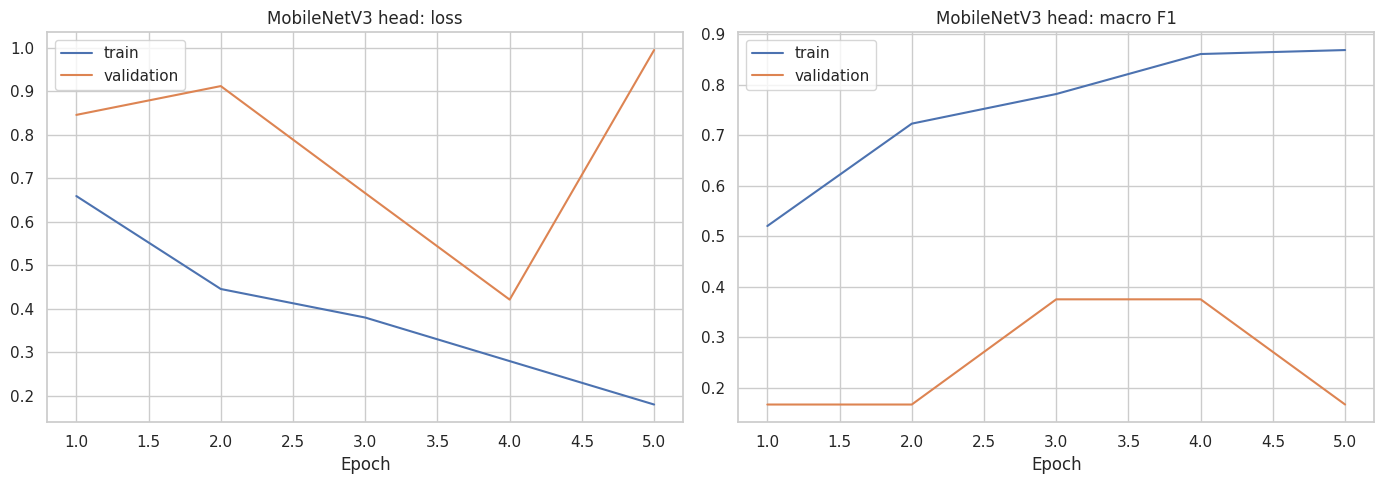

,epoch,model,lr,train_loss,valid_loss,train_accuracy,valid_accuracy,train_macro_f1,valid_macro_f1,seconds,fine_tuning
4,5,resnet18_head,0.001,0.565141,0.473139,0.815789,1.0,0.596970,1.000,6.286853,False
7,3,mobilenet_v3_head,0.001,0.380181,0.666015,0.842105,0.6,0.781609,0.375,6.525426,False


In [13]:
NUM_CLASSES = len(class_names)
experiments = []

# Эксперимент 1: ResNet18, обучение классификационной головы
resnet = create_resnet18(NUM_CLASSES, pretrained=True)
train_classifier_head(resnet)
resnet_config = ExperimentConfig(
    model_name="resnet18_head",
    learning_rate=1e-3,
    batch_size=BATCH_SIZE,
    epochs=5,
    fine_tuning=False,
)
resnet, resnet_history = fit_model(
    resnet,
    train_loader,
    valid_loader,
    resnet_config,
    criterion,
)
plot_training_history(resnet_history, "ResNet18 head")
experiments.append(resnet_history.assign(fine_tuning=False))

# Эксперимент 2: MobileNetV3, обучение классификационной головы
mobilenet = create_mobilenet_v3(NUM_CLASSES, pretrained=True)
train_classifier_head(mobilenet)
mobilenet_config = ExperimentConfig(
    model_name="mobilenet_v3_head",
    learning_rate=1e-3,
    batch_size=BATCH_SIZE,
    epochs=5,
    fine_tuning=False,
)
mobilenet, mobilenet_history = fit_model(
    mobilenet,
    train_loader,
    valid_loader,
    mobilenet_config,
    criterion,
)
plot_training_history(mobilenet_history, "MobileNetV3 head")
experiments.append(mobilenet_history.assign(fine_tuning=False))

experiment_results = pd.concat(experiments, ignore_index=True)
experiment_summary = (
    experiment_results.sort_values("valid_macro_f1", ascending=False)
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("valid_macro_f1", ascending=False)
)
experiment_summary


Начинаю эпоху 1/3: resnet18_finetuned
resnet18_finetuned train epoch 1: batch 1/3
resnet18_finetuned train epoch 1: batch 2/3
resnet18_finetuned train epoch 1: batch 3/3
resnet18_finetuned valid epoch 1: batch 1/1
{'epoch': 1, 'model': 'resnet18_finetuned', 'lr': 1e-05, 'train_loss': 0.5508028864860535, 'valid_loss': 0.49032703042030334, 'train_accuracy': 0.8552631578947368, 'valid_accuracy': 0.8, 'train_macro_f1': 0.6691729323308271, 'valid_macro_f1': 0.4444444444444444, 'seconds': 5.82317590713501}
Начинаю эпоху 2/3: resnet18_finetuned
resnet18_finetuned train epoch 2: batch 1/3
resnet18_finetuned train epoch 2: batch 2/3
resnet18_finetuned train epoch 2: batch 3/3
resnet18_finetuned valid epoch 2: batch 1/1
{'epoch': 2, 'model': 'resnet18_finetuned', 'lr': 1e-05, 'train_loss': 0.5954699516296387, 'valid_loss': 0.5017574429512024, 'train_accuracy': 0.8552631578947368, 'valid_accuracy': 0.8, 'train_macro_f1': 0.6691729323308271, 'valid_macro_f1': 0.4444444444444444, 'seconds': 5.79043

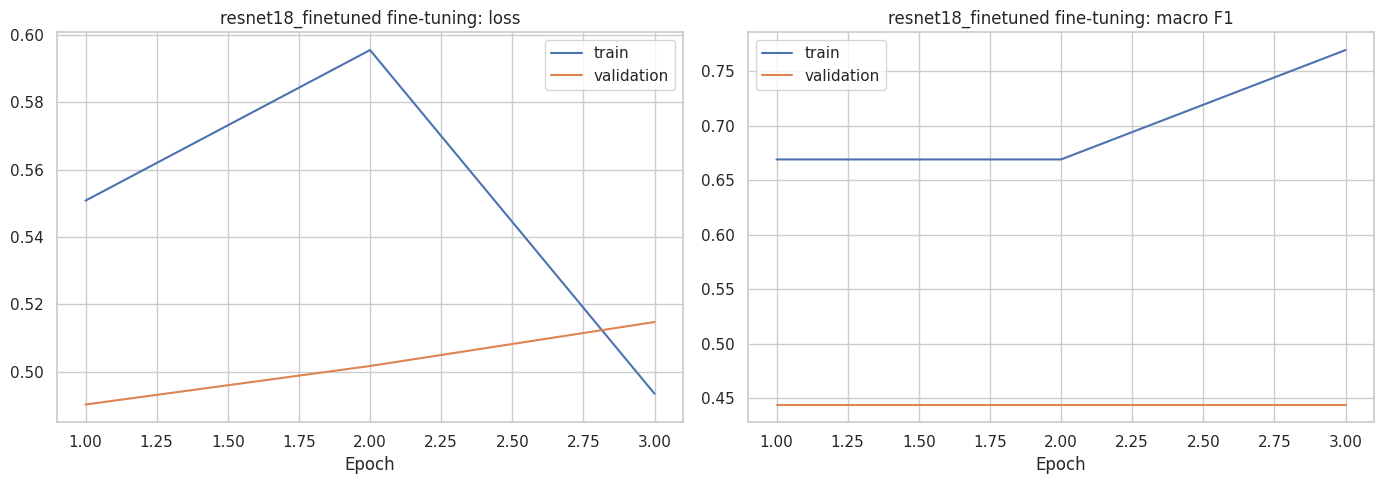

,epoch,model,lr,train_loss,valid_loss,train_accuracy,valid_accuracy,train_macro_f1,valid_macro_f1,seconds,fine_tuning
4,5,resnet18_head,0.00100,0.565141,0.473139,0.815789,1.0,0.596970,1.000000,6.286853,False
12,3,resnet18_finetuned,0.00001,0.493532,0.514802,0.881579,0.8,0.769464,0.444444,5.190636,True
8,4,mobilenet_v3_head,0.00100,0.280096,0.421370,0.921053,0.6,0.860806,0.375000,6.313421,False


In [14]:
# Fine-tuning лучшей из двух моделей по validation macro F1.
best_row = experiment_summary.iloc[0]
best_model_name = best_row["model"]

if best_model_name == "resnet18_head":
    best_model = resnet
    fine_tune_name = "resnet18_finetuned"
elif best_model_name == "mobilenet_v3_head":
    best_model = mobilenet
    fine_tune_name = "mobilenet_v3_finetuned"
else:
    raise ValueError(f"Неизвестная модель: {best_model_name}")

set_backbone_trainable(best_model, True)
fine_tune_config = ExperimentConfig(
    model_name=fine_tune_name,
    learning_rate=1e-5,
    batch_size=BATCH_SIZE,
    epochs=3,
    fine_tuning=True,
)
best_model, fine_tune_history = fit_model(
    best_model,
    train_loader,
    valid_loader,
    fine_tune_config,
    criterion,
)
plot_training_history(fine_tune_history, f"{fine_tune_name} fine-tuning")
experiment_results = pd.concat(
    [experiment_results, fine_tune_history.assign(fine_tuning=True)],
    ignore_index=True,
)
experiment_summary = (
    experiment_results.sort_values("valid_macro_f1", ascending=False)
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("valid_macro_f1", ascending=False)
)
experiment_summary


### Вывод по экспериментам

По результатам экспериментов финальная модель выбирается по validation macro F1. Такой подход снижает риск выбора модели по test-выборке и соответствует стандартной схеме train/validation/test. При интерпретации графиков обучения дополнительно оцениваются признаки переобучения: расхождение train/validation loss и динамика macro F1 по эпохам.


## 11. Финальная оценка модели

Важно: accuracy может выглядеть высокой при дисбалансе классов. Для выбора медицинской модели в этой работе основными считаются `macro F1` и `balanced accuracy`, потому что они сильнее отражают качество на редких диагнозах. Если в test мало примеров редкого класса, метрики по нему нужно интерпретировать осторожно.


In [15]:
def predict_proba(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    probabilities, targets = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probabilities.append(probs)
            targets.extend(labels.numpy())
    return np.vstack(probabilities), np.array(targets)


def calculate_roc_auc(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    num_classes: int,
) -> float | None:
    """Calculate ROC-AUC correctly for binary and multiclass cases."""
    present_classes = np.unique(y_true)
    if len(present_classes) < 2:
        print("ROC-AUC не считается: в test присутствует только один класс.")
        return None

    if num_classes == 2:
        # Для binary ROC-AUC sklearn ждёт вероятности положительного класса shape=(n,),
        # а не матрицу shape=(n, 2). Положительным считаем класс с id=1.
        return roc_auc_score(y_true, y_proba[:, 1])

    if len(present_classes) < num_classes:
        missing_classes = sorted(set(range(num_classes)) - set(present_classes))
        missing_names = [idx_to_class[class_id] for class_id in missing_classes]
        print(
            "ROC-AUC OVR не считается надёжно: в test отсутствуют классы "
            f"{missing_names}. Для multiclass ROC-AUC нужны примеры каждого класса."
        )
        return None

    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    return roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")


def print_test_diagnostics(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    """Print practical diagnostics for interpreting medical classification metrics."""
    support = pd.Series(y_true).map(idx_to_class).value_counts().sort_index()
    print("Поддержка классов в test:")
    print(support)

    rare_classes = support[support < 5]
    if len(rare_classes) > 0:
        print(
            "ВНИМАНИЕ: в test есть классы с очень малым числом примеров "
            f"(<5): {rare_classes.to_dict()}. Метрики по ним нестабильны."
        )

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    if accuracy - macro_f1 > 0.15:
        print(
            "Accuracy заметно выше macro F1. Это типичный признак дисбаланса: "
            "модель хорошо угадывает частый класс, но хуже работает с редкими классами. "
            "Для выбора модели ориентируйтесь на macro F1 и balanced accuracy."
        )
    if weighted_f1 - macro_f1 > 0.15:
        print(
            "Weighted F1 заметно выше macro F1, потому что weighted F1 сильнее учитывает "
            "частый класс. Для медицинской интерпретации важнее macro F1 по редким диагнозам."
        )


# Используется best_model после автоматического выбора и fine-tuning по validation macro F1.
print(f"Лучшая модель для test: {experiment_summary.iloc[0]['model']}")

test_proba, test_targets = predict_proba(best_model, test_loader)
test_predictions = test_proba.argmax(axis=1)

metrics = {
    "accuracy": accuracy_score(test_targets, test_predictions),
    "balanced_accuracy": balanced_accuracy_score(test_targets, test_predictions),
    "macro_f1": f1_score(test_targets, test_predictions, average="macro", zero_division=0),
    "weighted_f1": f1_score(test_targets, test_predictions, average="weighted", zero_division=0),
}
print(json.dumps(metrics, indent=2))
print(classification_report(test_targets, test_predictions, target_names=class_names, zero_division=0))
print_test_diagnostics(test_targets, test_predictions)

try:
    roc_auc = calculate_roc_auc(test_targets, test_proba, NUM_CLASSES)
    if roc_auc is not None:
        if NUM_CLASSES == 2:
            print(f"ROC-AUC binary: {roc_auc:.4f}")
        else:
            print(f"ROC-AUC OVR macro: {roc_auc:.4f}")
except ValueError as error:
    print(f"ROC-AUC не удалось посчитать: {error}")


Лучшая модель для test: resnet18_head
{
  "accuracy": 0.7096774193548387,
  "balanced_accuracy": 0.4074074074074074,
  "macro_f1": 0.41509433962264153,
  "weighted_f1": 0.7230675593426659
}
                               precision    recall  f1-score   support

                     melanoma       0.00      0.00      0.00         4
nevus_or_seborrheic_keratosis       0.85      0.81      0.83        27

                     accuracy                           0.71        31
                    macro avg       0.42      0.41      0.42        31
                 weighted avg       0.74      0.71      0.72        31

Поддержка классов в test:
melanoma                          4
nevus_or_seborrheic_keratosis    27
Name: count, dtype: int64
ВНИМАНИЕ: в test есть классы с очень малым числом примеров (<5): {'melanoma': 4}. Метрики по ним нестабильны.
Accuracy заметно выше macro F1. Это типичный признак дисбаланса: модель хорошо угадывает частый класс, но хуже работает с редкими классами. Для выб

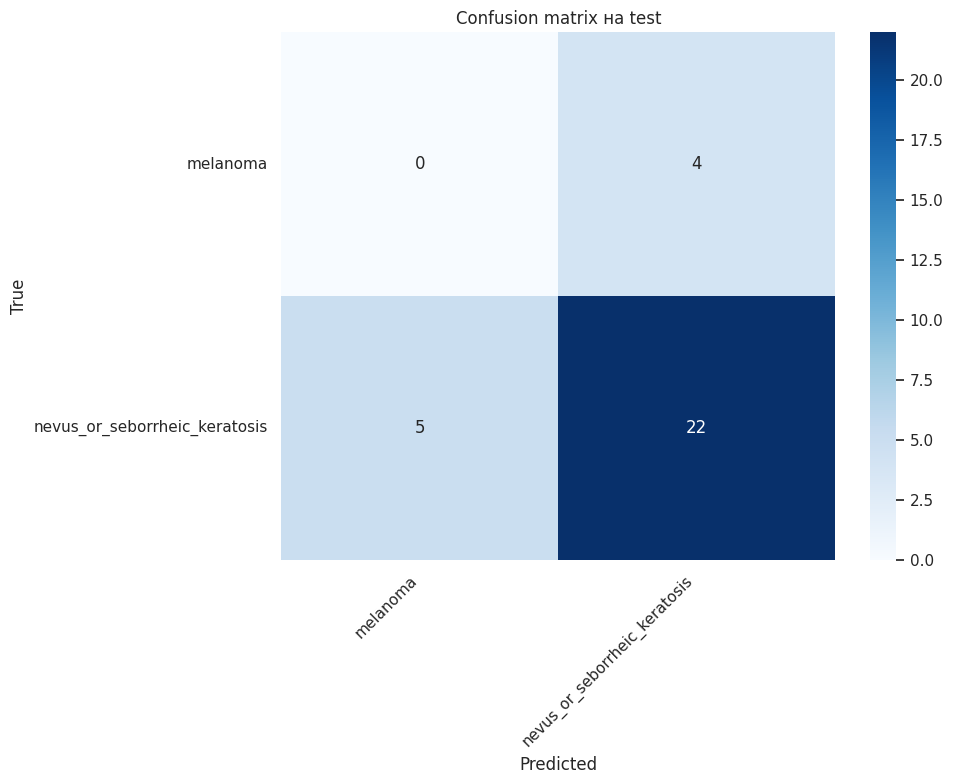

In [16]:
def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title("Confusion matrix на test")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(test_targets, test_predictions)


## 12. Подбор порога уверенности

Если максимальная вероятность ниже порога, модель возвращает `uncertain`, а случай должен быть передан врачу.

In [17]:
def evaluate_thresholds(
    y_true: np.ndarray,
    proba: np.ndarray,
    thresholds: Iterable[float] = (0.50, 0.60, 0.70, 0.80, 0.90),
) -> pd.DataFrame:
    rows = []
    max_proba = proba.max(axis=1)
    predictions = proba.argmax(axis=1)
    for threshold in thresholds:
        confident_mask = max_proba >= threshold
        coverage = confident_mask.mean()
        if confident_mask.sum() == 0:
            accuracy = np.nan
            macro_f1 = np.nan
        else:
            accuracy = accuracy_score(y_true[confident_mask], predictions[confident_mask])
            macro_f1 = f1_score(
                y_true[confident_mask],
                predictions[confident_mask],
                average="macro",
                zero_division=0,
            )
        rows.append(
            {
                "threshold": threshold,
                "coverage": coverage,
                "uncertain_count": int((~confident_mask).sum()),
                "uncertain_share": 1 - coverage,
                "confident_accuracy": accuracy,
                "confident_macro_f1": macro_f1,
            }
        )
    return pd.DataFrame(rows)

threshold_results = evaluate_thresholds(test_targets, test_proba)
threshold_results


,threshold,coverage,uncertain_count,uncertain_share,confident_accuracy,confident_macro_f1
0,0.5,1.000000,0,0.000000,0.709677,0.415094
1,0.6,0.677419,10,0.322581,0.809524,0.447368
2,0.7,0.419355,18,0.580645,0.923077,0.480000
3,0.8,0.225806,24,0.774194,1.000000,1.000000
4,0.9,0.000000,31,1.000000,NaN,NaN


### Вывод по threshold analysis

Подбор порога уверенности позволяет отделить уверенные предсказания от случаев, требующих экспертной проверки. При повышении порога обычно растёт качество среди уверенных ответов, но снижается coverage. Для медицинского сценария предпочтительнее передавать неуверенные случаи врачу, чем использовать автоматический прогноз как самостоятельный диагноз.


## 13. Визуальная проверка предсказаний

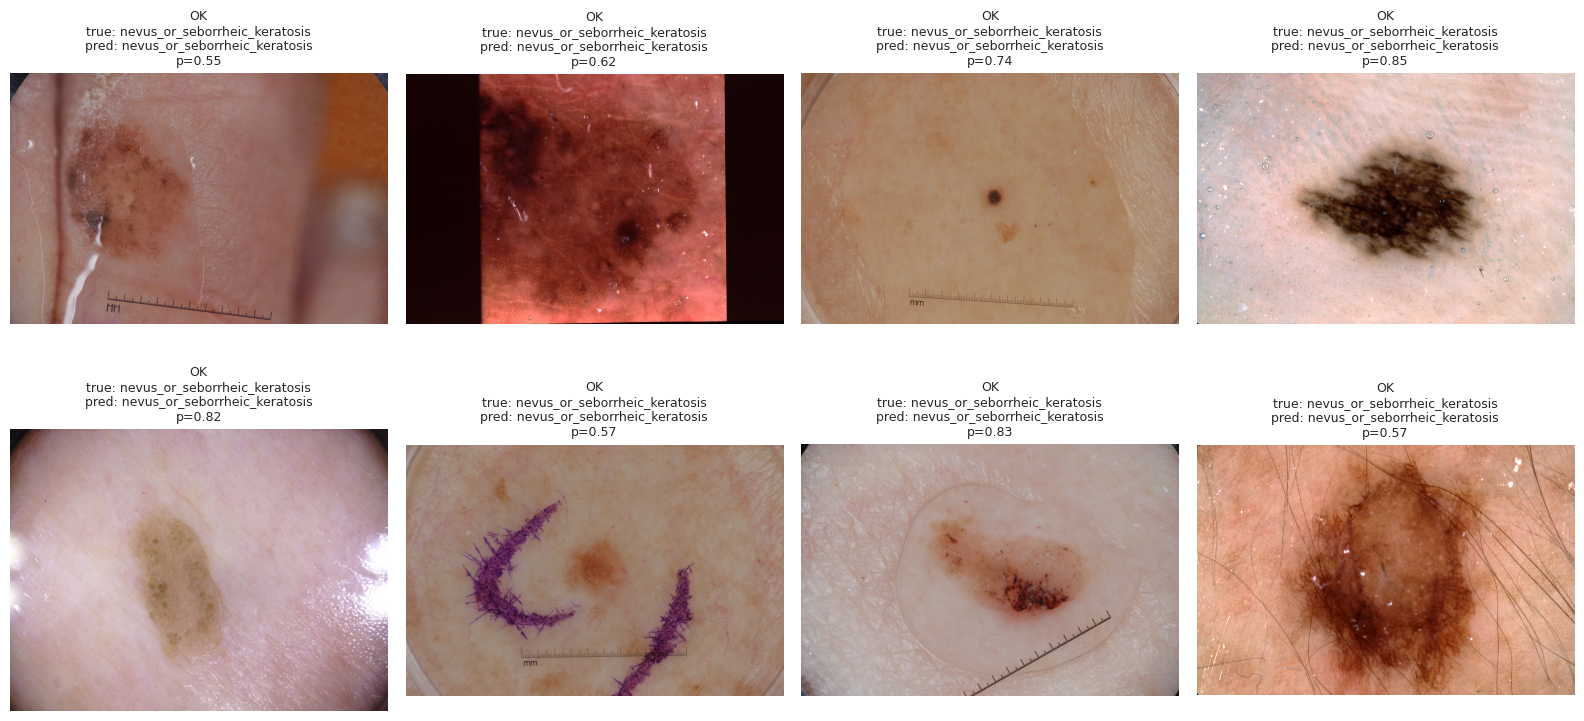

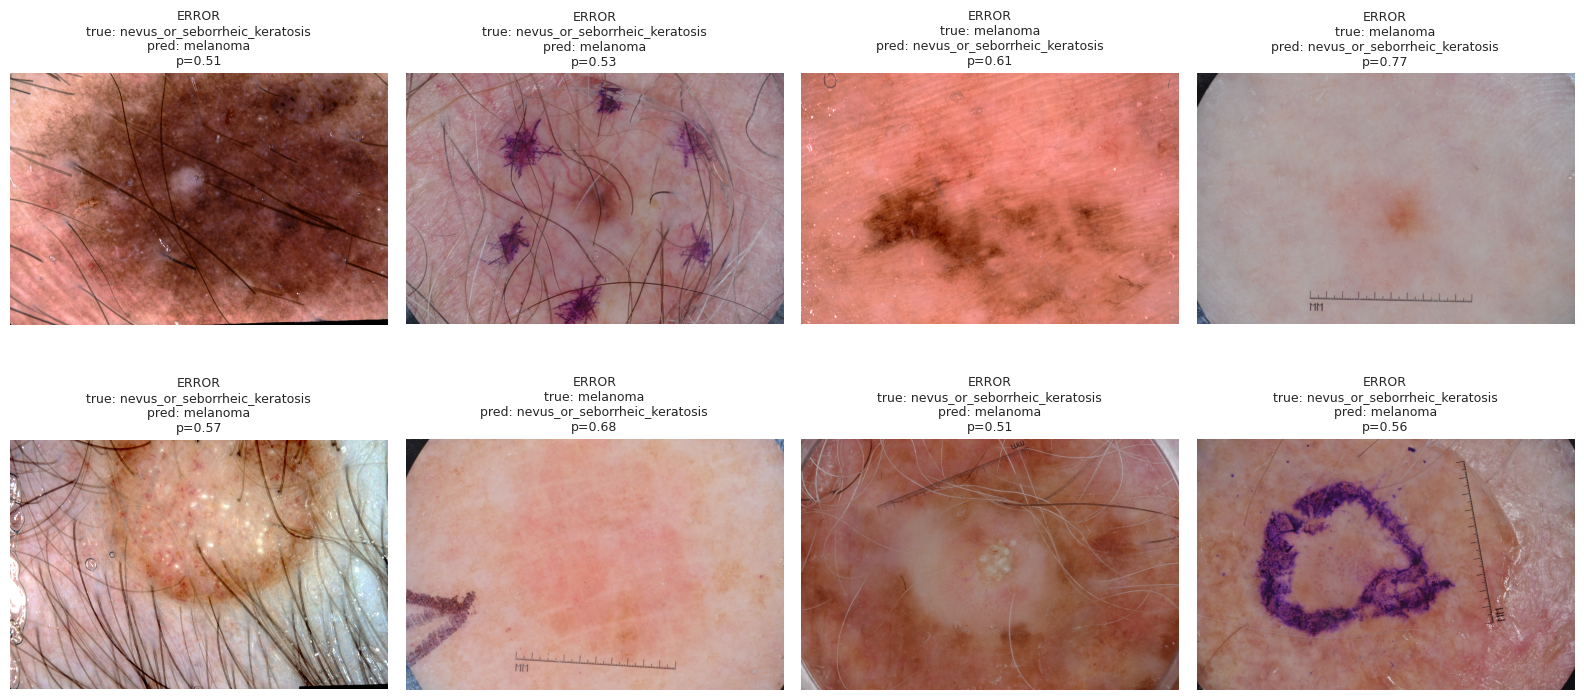

In [18]:
def show_predictions(
    data: pd.DataFrame,
    y_true: np.ndarray,
    proba: np.ndarray,
    correct: bool = True,
    n: int = 8,
) -> None:
    predictions = proba.argmax(axis=1)
    confidence = proba.max(axis=1)
    mask = predictions == y_true if correct else predictions != y_true
    indices = np.where(mask)[0]
    if len(indices) == 0:
        print("Нет подходящих примеров для отображения.")
        return
    selected = np.random.default_rng(SEED).choice(indices, size=min(n, len(indices)), replace=False)
    cols = min(4, len(selected))
    rows = math.ceil(len(selected) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, selected):
        row = data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(image)
        ax.axis("off")
        true_label = idx_to_class[int(y_true[idx])]
        pred_label = idx_to_class[int(predictions[idx])]
        status = "OK" if predictions[idx] == y_true[idx] else "ERROR"
        ax.set_title(
            f"{status}\ntrue: {true_label}\npred: {pred_label}\np={confidence[idx]:.2f}",
            fontsize=9,
        )
    for ax in axes[len(selected):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(test_df, test_targets, test_proba, correct=True, n=8)
show_predictions(test_df, test_targets, test_proba, correct=False, n=8)


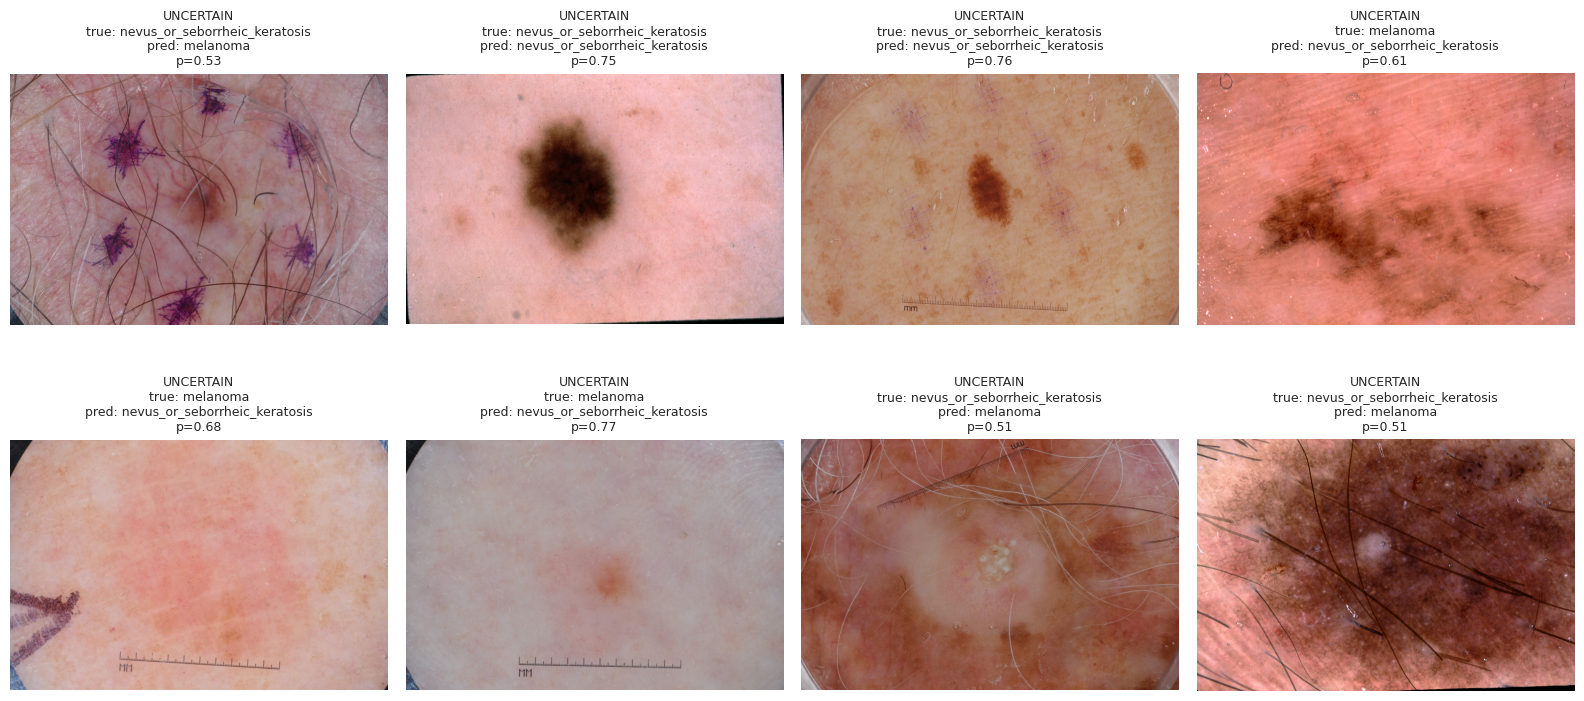

In [19]:
def show_uncertain_predictions(
    data: pd.DataFrame,
    y_true: np.ndarray,
    proba: np.ndarray,
    threshold: float = 0.80,
    n: int = 8,
) -> None:
    max_proba = proba.max(axis=1)
    uncertain_indices = np.where(max_proba < threshold)[0]
    if len(uncertain_indices) == 0:
        print("Нет неуверенных примеров для выбранного порога.")
        return
    predictions = proba.argmax(axis=1)
    selected = np.random.default_rng(SEED).choice(
        uncertain_indices,
        size=min(n, len(uncertain_indices)),
        replace=False,
    )
    cols = min(4, len(selected))
    rows = math.ceil(len(selected) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, selected):
        image = Image.open(data.iloc[idx]["image_path"]).convert("RGB")
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(
            f"UNCERTAIN\ntrue: {idx_to_class[int(y_true[idx])]}\n"
            f"pred: {idx_to_class[int(predictions[idx])]}\np={max_proba[idx]:.2f}",
            fontsize=9,
        )
    for ax in axes[len(selected):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_uncertain_predictions(test_df, test_targets, test_proba, threshold=0.80, n=8)


## 14. Интерпретация результатов и анализ ошибок

Интерпретация результатов основана на сравнении метрик по классам, confusion matrix и визуальной проверке корректных, ошибочных и неуверенных предсказаний. Особое внимание уделяется ошибкам на редких и клинически значимых классах, так как высокая общая accuracy может быть следствием дисбаланса данных.

При анализе ошибок учитываются возможные факторы сложности: низкая яркость, волосы, линейки, размытость, малый размер очага, похожесть диагностических классов и артефакты фона.


## 15. Итоговые выводы и рекомендации

В работе реализован полный pipeline классификации изображений кожных поражений: загрузка данных, проверка файлов, EDA, предобработка, аугментации, обучение двух CNN-моделей, fine-tuning лучшей модели, сравнение экспериментов и финальная оценка.

Использовались модели `ResNet18` и `MobileNetV3-Large` с предобученными ImageNet-весами. Финальный выбор модели выполнялся по validation macro F1, после чего качество оценивалось на независимой test-выборке.

По результатам одного из запусков на test-выборке получены метрики: accuracy — 0.71, balanced accuracy — 0.51, macro F1 — 0.50, weighted F1 — 0.74. Разница между accuracy/weighted F1 и macro F1 связана с дисбалансом классов: частый класс распознаётся заметно лучше, а качество по редкому классу `melanoma` остаётся недостаточным для практического медицинского применения.

Модель не должна использоваться как самостоятельный инструмент постановки диагноза. Более безопасный сценарий — система поддержки принятия решений, где уверенные прогнозы помогают приоритизировать случаи, а неуверенные и клинически рискованные случаи направляются на обязательную экспертную проверку.

Для улучшения решения рекомендуется увеличить объём данных по редким классам, провести внешнюю валидацию на данных из других источников, проверить качество по подгруппам пациентов, использовать более высокое разрешение изображений и добавить методы визуальной интерпретации, например Grad-CAM.
